# SIM 700s — Hole Deformation Characterization (DEFC2)

Plots the evolution of hole-deformation statistics computed in `DEFC2` over the compression step (Step-1).

**DEFC2 quantities** (all indexed over time, statistics taken across holes):
- `etaC_A` — area localization index: `1 - std(A_norm) / stdM`
- `etaC_R` — aspect-ratio localization index: `1 - std(R_norm) / stdM`
- `A_mean, A_std, A_min, A_max` — cross-hole stats of normalized area
- `R_mean, R_std, R_min, R_max` — cross-hole stats of normalized aspect ratio

where `stdM = 0.5 * sqrt(n_holes / (n_holes - 1))` is the theoretical maximum standard deviation
and normalization is relative to `t = 0` (start of Step-1).

In [ ]:
import sys, os, pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
SIMS = list(range(700, 705))


In [ ]:
def load_pkl(path):
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

defc2 = {}
for sim in SIMS:
    path = f'{RESULTS_DIR}/DATA_PICK_{sim}_DEFC2.pkl'
    d = load_pkl(path)
    if d is not None:
        defc2[sim] = d
        print(f'SIM {sim}: loaded — n_holes={d["n_holes"]}, stdM={d["stdM"]:.4f}, n_t={len(d["t"])}')
    else:
        print(f'SIM {sim}: DEFC2 not found, skipping')


SIM 700: loaded — n_holes=77, stdM=0.5033, n_t=201
SIM 701: loaded — n_holes=77, stdM=0.5033, n_t=201
SIM 702: loaded — n_holes=77, stdM=0.5033, n_t=201
SIM 703: loaded — n_holes=77, stdM=0.5033, n_t=201
SIM 704: loaded — n_holes=77, stdM=0.5033, n_t=201


## 1 — Localization indices `etaC_A` and `etaC_R`

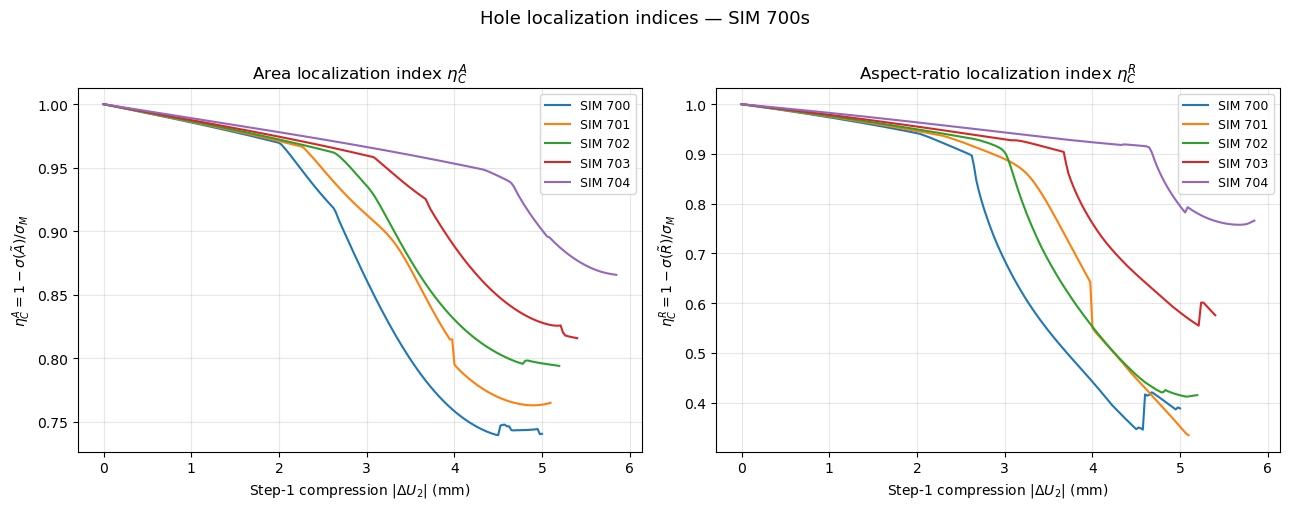

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
cmap = plt.get_cmap('tab10')

for idx, (sim, d) in enumerate(defc2.items()):
    x = np.abs(np.array(d['displacement']) - d['displacement'][0])
    color = cmap(idx)
    axes[0].plot(x, d['etaC_A'], color=color, label=f'SIM {sim}')
    axes[1].plot(x, d['etaC_R'], color=color, label=f'SIM {sim}')

for ax, title, ylabel in zip(
    axes,
    [r'Area localization index $\eta_C^A$', r'Aspect-ratio localization index $\eta_C^R$'],
    [r'$\eta_C^A = 1 - \sigma(\tilde{A}) / \sigma_M$',
     r'$\eta_C^R = 1 - \sigma(\tilde{R}) / \sigma_M$']
):
    ax.set_xlabel('Step-1 compression $|\\Delta U_2|$ (mm)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Hole localization indices — SIM 700s', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


## 2 — Normalized area statistics (`A_mean`, `A_std`, `A_min`, `A_max`)

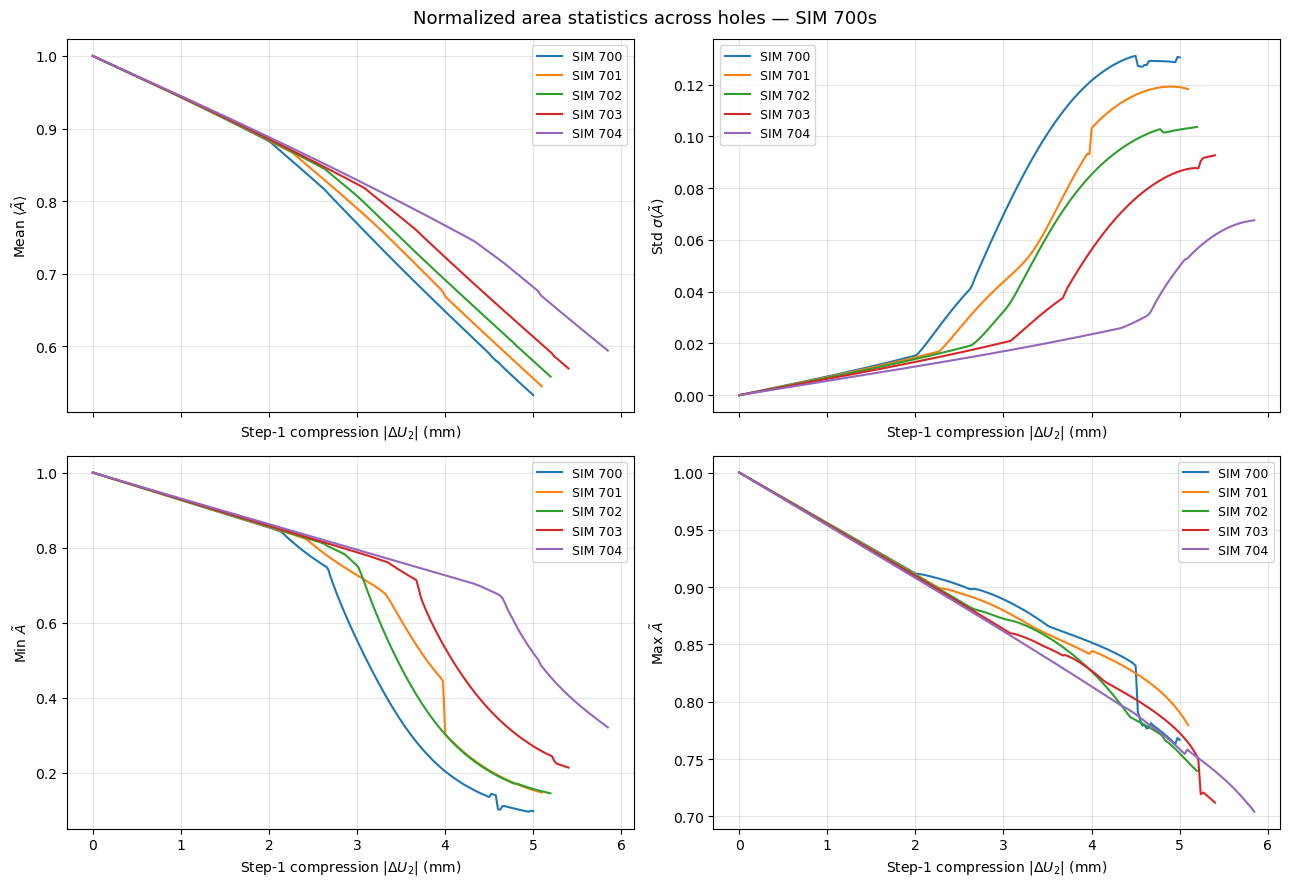

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
axes = axes.flatten()
cmap = plt.get_cmap('tab10')

stats_A = [
    ('A_mean', r'Mean $\langle \tilde{A} \rangle$'),
    ('A_std',  r'Std $\sigma(\tilde{A})$'),
    ('A_min',  r'Min $\tilde{A}$'),
    ('A_max',  r'Max $\tilde{A}$'),
]

for ax, (key, label) in zip(axes, stats_A):
    for idx, (sim, d) in enumerate(defc2.items()):
        x = np.abs(np.array(d['displacement']) - d['displacement'][0])
        ax.plot(x, d[key], color=cmap(idx), label=f'SIM {sim}')
    ax.set_ylabel(label)
    ax.set_xlabel('Step-1 compression $|\\Delta U_2|$ (mm)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Normalized area statistics across holes — SIM 700s', fontsize=13)
fig.tight_layout()
plt.show()


## 3 — Normalized aspect-ratio statistics (`R_mean`, `R_std`, `R_min`, `R_max`)

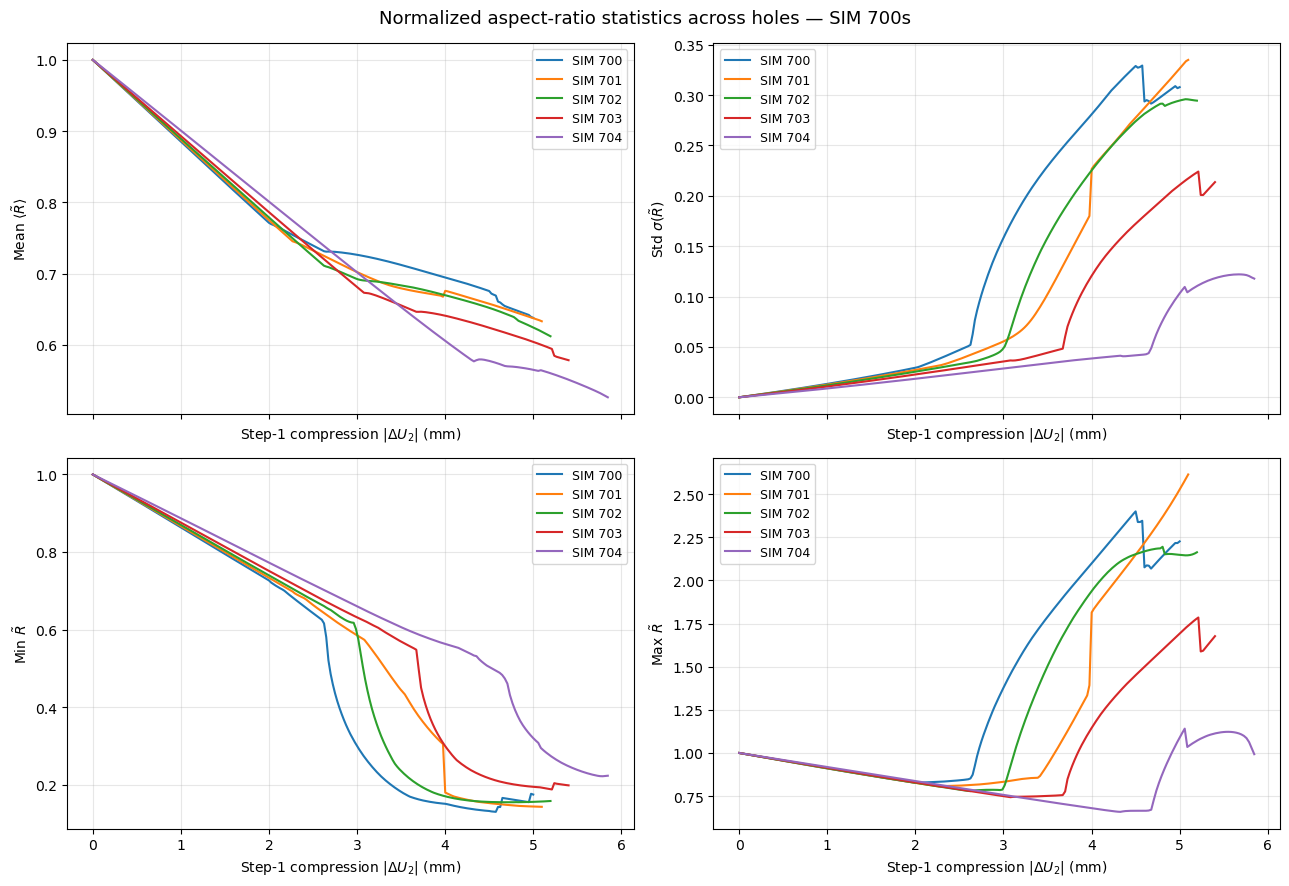

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
axes = axes.flatten()
cmap = plt.get_cmap('tab10')

stats_R = [
    ('R_mean', r'Mean $\langle \tilde{R} \rangle$'),
    ('R_std',  r'Std $\sigma(\tilde{R})$'),
    ('R_min',  r'Min $\tilde{R}$'),
    ('R_max',  r'Max $\tilde{R}$'),
]

for ax, (key, label) in zip(axes, stats_R):
    for idx, (sim, d) in enumerate(defc2.items()):
        x = np.abs(np.array(d['displacement']) - d['displacement'][0])
        ax.plot(x, d[key], color=cmap(idx), label=f'SIM {sim}')
    ax.set_ylabel(label)
    ax.set_xlabel('Step-1 compression $|\\Delta U_2|$ (mm)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Normalized aspect-ratio statistics across holes — SIM 700s', fontsize=13)
fig.tight_layout()
plt.show()


## 4 — Combined view: `etaC_A` vs `etaC_R`

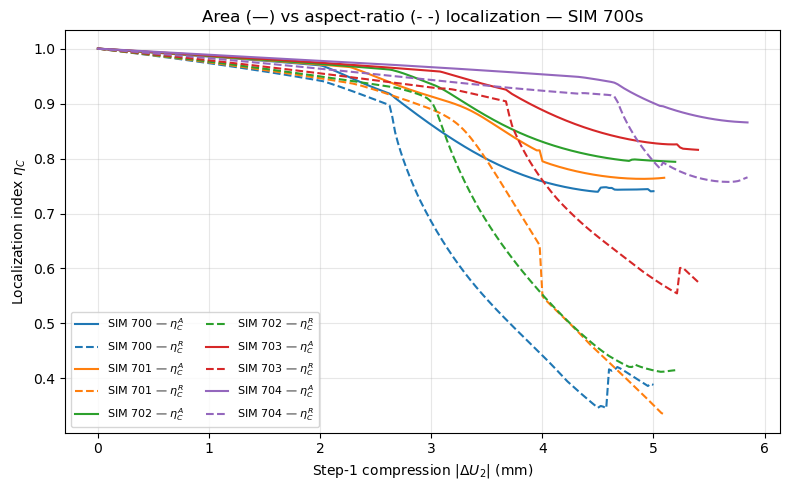

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.get_cmap('tab10')

for idx, (sim, d) in enumerate(defc2.items()):
    x = np.abs(np.array(d['displacement']) - d['displacement'][0])
    color = cmap(idx)
    ax.plot(x, d['etaC_A'], color=color, ls='-',  label=f'SIM {sim} — $\\eta_C^A$')
    ax.plot(x, d['etaC_R'], color=color, ls='--', label=f'SIM {sim} — $\\eta_C^R$')

ax.set_xlabel('Step-1 compression $|\\Delta U_2|$ (mm)')
ax.set_ylabel(r'Localization index $\eta_C$')
ax.set_title('Area (—) vs aspect-ratio (- -) localization — SIM 700s')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
